# MIRIPVIR25 - Draft 00 - Simulations

## Summary

Two main problems in the detection of co-ocurrences at the meta-transcriptomic levels are the strong host-abudnance among reads, and the influence of gene expression in the resulting sequences. Therefore, it is very important to assess our capabilities for taxa detection. 

In this notebook, we analyze the performance of four different taxonomic detection methods in a set of 75 meta-transcriptome simulations.

In [ ]:
import numpy as np
import pandas as pd
import tqdm
import seaborn as sns
import taxoniq
from miripvir.metrics import assess_taxonomic_classification_metrics
from miripvir.data import load_mmseqs2_tsv
import matplotlib.pyplot as plt
from scipy.stats import f_oneway,  dunnett
plt.rcParams['svg.fonttype'] = 'none'


method_palette = {
    "mmseqs2-gtdb-c0": "#2E28F6",
    "mmseqs2-gtdb-c5": "#338BF4",
    "mmseqs2-gtdb-c10": "#26DAF5",
    "kraken2-low": "#BE6AF5",
    "kraken2-medium": "#F551A6",
    "kraken2-high": "#FF2B1A",
    "motus-g1": "#FFD030",
    "motus-g2": "#F6A74D",
    "motus-g3": "#F6A799",
    "metaphlan": "#0C9459"
}

## Load reference data

In [2]:
def fault_tolerant_rank(x):
    try:
        return taxoniq.Taxon(x).rank.name
    except KeyError:
        return pd.NA

In [3]:
with open("raw/benchmark/reference/.reports") as f:
    reports_input = list(map(lambda x: x.strip(), f.readlines()))

def load_report(file, label):
    u = pd.read_csv(file, sep=';').query('strand == "R1"')
    u['label'] = label
    return u

reports = pd.concat([load_report("raw/benchmark/reference/" + file, file.replace(".abundances.txt", "")) for file in reports_input])
reports['host_abundance'] = reports['label'].apply(lambda x: x.split(".")[1])
reports['rep'] =  reports['label'].apply(lambda x: x.split(".")[2])
reports

,index,taxid,count,strand,label,host_abundance,rep
0,0,3702,0.899323,R1,test-7.90.001,90,001
1,1,1736471,0.070238,R1,test-7.90.001,90,001
2,2,2014239,0.004533,R1,test-7.90.001,90,001
3,3,550,0.004489,R1,test-7.90.001,90,001
4,4,294,0.003907,R1,test-7.90.001,90,001
...,...,...,...,...,...,...,...
80,80,933059,0.000003,R1,test-7.99.025,99,025
81,81,229920,0.000003,R1,test-7.99.025,99,025
82,82,1417072,0.000003,R1,test-7.99.025,99,025
83,83,1437360,0.000001,R1,test-7.99.025,99,025


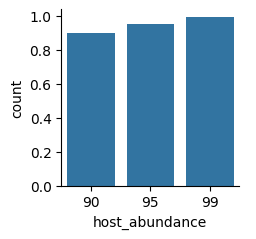

In [4]:
sns.catplot(
    data=reports.query('taxid == 3702'),
    x='host_abundance', y='count', kind='bar',
    errorbar='sd', height=2.5
)

## Load results



### Kraken2

In [5]:
with open("raw/benchmark/kraken-high/.input") as f:
    kraken2_input = [i.strip() for i in f.readlines()]

def kraken2_load(file, label, method):
    kraken2_df = pd.read_csv(file, sep=',', index_col=None)
    kraken2_df = kraken2_df.rename(columns={'library': 'method', 'taxonid': 'taxid'}).drop(columns=['classification-ratio'])
    kraken2_df['rank'] = kraken2_df['taxid'].apply(fault_tolerant_rank)
    kraken2_df = kraken2_df.dropna(subset=['rank']).query('rank == "species"').drop(columns=['rank']).copy()
    kraken2_df['method'] = method
    kraken2_df['ncbi_taxid'] = kraken2_df['taxid']
    kraken2_df = kraken2_df[['taxid', 'ncbi_taxid', 'method', 'scientific_name']]
    kraken2_df['label'] = label
    return kraken2_df

kraken2_df = pd.concat(
    [kraken2_load("raw/benchmark/kraken-high/" + file, file.replace(".taxonomy.tsv", ""), "kraken2-high") for file in kraken2_input] + 
    [kraken2_load("raw/benchmark/kraken-medium/" + file, file.replace(".taxonomy.tsv", ""), "kraken2-medium") for file in kraken2_input] +
    [kraken2_load("raw/benchmark/kraken-low/" + file, file.replace(".taxonomy.tsv", ""), "kraken2-low") for file in kraken2_input]
)
kraken2_df

,taxid,ncbi_taxid,method,scientific_name,label
0,3702,3702,kraken2-high,Arabidopsis thaliana,test-7.90.001
19,294,294,kraken2-high,Pseudomonas fluorescens,test-7.90.001
22,1464,1464,kraken2-high,Paenibacillus larvae,test-7.90.001
25,550,550,kraken2-high,Enterobacter cloacae,test-7.90.001
28,114615,114615,kraken2-high,Bradyrhizobium sp. ORS 278,test-7.90.001
...,...,...,...,...,...
257,3914,3914,kraken2-low,Vigna angularis,test-7.99.025
263,1778,1778,kraken2-low,Mycobacterium gordonae,test-7.99.025
264,2860336,2860336,kraken2-low,Devosia salina,test-7.99.025
266,38727,38727,kraken2-low,Panicum virgatum,test-7.99.025


### Motus

In [6]:
with open("raw/benchmark/motus-high/.input") as f:
    motus_input = [i.strip() for i in f.readlines()]

def load_motus(file, label): 
    tmp = pd.read_csv(file, sep="\t", comment='#', header=None, names=['otu', 'scientific_name', 'taxid', 'count'])
    tmp['label'] = label
    return tmp

motus_df_g1 = pd.concat(
    [load_motus('raw/benchmark/motus-low/' + file, file.replace(".classification.csv", "")) for file in motus_input],
).reset_index().dropna(subset=['scientific_name']).drop(columns=['index']).query('otu != "unassigned"').copy()
motus_df_g1['method'] = 'motus-g1'
motus_df_g2 = pd.concat(
    [load_motus('raw/benchmark/motus-medium/' + file, file.replace(".classification.csv", "")) for file in motus_input],
).reset_index().dropna(subset=['scientific_name']).drop(columns=['index']).query('otu != "unassigned"').copy()
motus_df_g2['method'] = 'motus-g2'
motus_df_g3 = pd.concat(
    [load_motus('raw/benchmark/motus-high/' + file, file.replace(".classification.csv", "")) for file in motus_input],
).reset_index().dropna(subset=['scientific_name']).drop(columns=['index']).query('otu != "unassigned"').copy()
motus_df_g3['method'] = 'motus-g3'

motus_df = pd.concat([motus_df_g1, motus_df_g2, motus_df_g3])
motus_df = motus_df.dropna(subset=['taxid']).copy()
motus_df['taxid'] = motus_df['taxid'].astype(int)
motus_df

,otu,scientific_name,taxid,count,label,method
1,ref_mOTU_v31_00099,Salmonella enterica,28901,1,test-7.90.001,motus-g1
3,ref_mOTU_v31_00140,Pseudomonas chlororaphis [Pseudomonas sp. GM17...,587753,1,test-7.90.001,motus-g1
4,ref_mOTU_v31_00259,Acinetobacter baumannii,470,1,test-7.90.001,motus-g1
5,ref_mOTU_v31_00340,Staphylococcus aureus [Staphylococcus aureus/S...,1280,4,test-7.90.001,motus-g1
6,ref_mOTU_v31_00404,Frateuria aurantia,81475,2,test-7.90.001,motus-g1
...,...,...,...,...,...,...
1286,ref_mOTU_v31_01804,Campylobacter jejuni,197,3,test-7.99.025,motus-g3
1287,ref_mOTU_v31_02680,Fusicatenibacter saccharivorans [Fusicatenibac...,1150298,1,test-7.99.025,motus-g3
1288,ref_mOTU_v31_03164,Methanobrevibacter boviskoreani [Methanobrevib...,1348249,3,test-7.99.025,motus-g3
1290,ref_mOTU_v31_08629,archaeon GW2011_AR20,1579378,2,test-7.99.025,motus-g3


### MethaPhlAN

In [7]:
def load_metaphlan(file, label):
    u = pd.read_csv(file, comment='#', header=None, names=['clade', 'ncbi', 'abundance', '_'], sep='\t')
    u["label"] = label
    return u

with open("raw/benchmark/metaphlan/.input") as f:
    metaphlan_input = [i.strip() for i in f.readlines()]

metaphlan_df = pd.concat(
    [load_metaphlan('raw/benchmark/metaphlan/' + file, file.replace(".metaphlan", "")) for file in metaphlan_input],
).reset_index().dropna(subset=['ncbi']).drop(columns=['index']).copy()
metaphlan_df['taxid'] = metaphlan_df['ncbi'].astype(str).apply(lambda x: x.split("|")[-1])
metaphlan_df = metaphlan_df.query('taxid != ""').copy()
metaphlan_df['taxid'] = metaphlan_df['taxid'].astype(int)
metaphlan_df['rank'] = metaphlan_df['taxid'].apply(fault_tolerant_rank)
metaphlan_df = metaphlan_df.dropna(subset=['rank']).query('rank == "species"').copy()
metaphlan_df['method'] = 'metaphlan'
metaphlan_df = metaphlan_df[['method', 'label', 'taxid']]
metaphlan_df


,method,label,taxid
62,metaphlan,test-7.90.001,1736471
64,metaphlan,test-7.90.001,81475
65,metaphlan,test-7.90.001,550
66,metaphlan,test-7.90.001,2596920
67,metaphlan,test-7.90.001,1280
...,...,...,...
7232,metaphlan,test-7.99.025,1494960
7233,metaphlan,test-7.99.025,114616
7234,metaphlan,test-7.99.025,53972
7235,metaphlan,test-7.99.025,1736289


### MMSeqs2 - GTDB

In [ ]:
with open("raw/benchmark/mmseqs/.input") as f:
    mmseqs2_input = [i.strip() for i in f.readlines()]
def gtdb_load(path, file, label, threshold):
    mmseqs2_gtdb_df = load_mmseqs2_tsv(
        path=path, file=file, library=label
    )
    mmseqs2_gtdb_df = mmseqs2_gtdb_df.query('level == "species"').value_counts(['taxid', 'species_name', 'library']).reset_index().query(f'count > {threshold}').rename(columns={'species_name':'scientific_name', 'library':'label'}).copy()
    mmseqs2_gtdb_df = mmseqs2_gtdb_df[['taxid', 'label', 'scientific_name']]#.rename(columns={'taxid': 'gtdb_id'})
    return mmseqs2_gtdb_df

gtdb_df = pd.concat([gtdb_load(
    path="raw/benchmark/mmseqs/", 
    file=file, label=file.replace(".taxonomy.tsv", ""), threshold=0) for file in mmseqs2_input]
)
gtdb_df['method'] = 'mmseqs2-gtdb-c0'

## Accuracy assessment

The following code block allows my `assess_taxonomic_classification_metrics` to work. This is aimed to enable assessments agains the GTDB database, where
more than one NCBI species might be represented by a single GTDB species. 

In [ ]:
metadata = pd.read_csv("../../data/taxonomy/bac120_metadata.tsv", sep='\t')
gtdb_reference = pd.read_csv("../../data/taxonomy/gtdb-taxdump/mapping_genomes", sep='\s+', header=None, names=['accession', 'gtdb_id'])
s1 = pd.merge(reports, metadata[['ncbi_taxid', 'accession']], left_on='taxid', right_on='ncbi_taxid')
s2 = pd.merge(s1, gtdb_reference, left_on='accession', right_on='accession')
reference_gtdb = s2.groupby(by=['ncbi_taxid', 'label'])['gtdb_id'].apply(list)
reference_ncbi = reports.groupby(by=['taxid', 'label'])['taxid'].apply(list)
reference_gtdb = reference_gtdb.reset_index().groupby('label')['gtdb_id'].apply(list)
reference_ncbi = reference_ncbi.reset_index(level=1).groupby('label')['taxid'].apply(list)
reference_ncbi

label
test-7.90.001    [[69], [294], [305], [470], [550], [1393], [14...
test-7.90.002    [[69], [294], [305], [470], [550], [1393], [14...
test-7.90.003    [[69], [294], [305], [470], [550], [1393], [14...
test-7.90.004    [[69], [294], [305], [470], [550], [1393], [14...
test-7.90.005    [[69], [294], [305], [470], [550], [1393], [14...
                                       ...                        
test-7.99.021    [[292], [294], [346], [373], [550], [1270], [2...
test-7.99.022    [[292], [294], [346], [373], [550], [1270], [2...
test-7.99.023    [[292], [294], [346], [373], [550], [1270], [2...
test-7.99.024    [[292], [294], [346], [373], [550], [1270], [2...
test-7.99.025    [[292], [294], [346], [373], [550], [1270], [2...
Name: taxid, Length: 75, dtype: object

In [ ]:
kraken2_hits_df = kraken2_df.groupby(['method', 'label'])['ncbi_taxid'].apply(list).reset_index()
kraken2_hits_df = pd.merge(kraken2_hits_df, reference_ncbi, on='label', how='right')
kraken2_hits_df = kraken2_hits_df.dropna(subset=['method'])
kraken2_hits_df['report'] = kraken2_hits_df.apply(lambda x: assess_taxonomic_classification_metrics(x.taxid, x.ncbi_taxid, ""), axis=1)
kraken2_hits_df['TP'] = kraken2_hits_df['report'].apply(lambda x: x['TP'])
kraken2_hits_df['FN'] = kraken2_hits_df['report'].apply(lambda x: x['FN'])
kraken2_hits_df['FP'] = kraken2_hits_df['report'].apply(lambda x: x['FP'])
kraken2_hits_df['Q'] = kraken2_hits_df['report'].apply(lambda x: x['Q'])
kraken2_hits_df['P'] = kraken2_hits_df['report'].apply(lambda x: x['P'])
kraken2_hits_df['sensitivity'] = kraken2_hits_df['report'].apply(lambda x: x['TP'] / (x['TP'] + x['FN']))
kraken2_hits_df['FDR'] = kraken2_hits_df['report'].apply(lambda x: x['FP'] / (x['TP'] + x['FP']))
kraken2_hits_df

,method,label,ncbi_taxid,taxid,report,TP,FN,FP,Q,P,sensitivity,FDR
0,kraken2-high,test-7.90.001,"[3702, 294, 1464, 550, 114615, 664643, 1851544...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 16, 'FP': 8, 'FN': 63, 'P...",16,63,8,79,24,0.202532,0.333333
1,kraken2-low,test-7.90.001,"[3702, 550, 294, 90675, 9606, 321984, 114615, ...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 24, 'FP': 262, 'FN': 55, ...",24,55,262,79,286,0.303797,0.916084
2,kraken2-medium,test-7.90.001,"[3702, 294, 550, 1464, 114615, 664643, 90675, ...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 23, 'FP': 35, 'FN': 56, '...",23,56,35,79,58,0.291139,0.603448
3,kraken2-high,test-7.90.002,"[3702, 305, 1560345, 3092262, 108015, 1464, 56...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 21, 'FP': 16, 'FN': 58, '...",21,58,16,79,37,0.265823,0.432432
4,kraken2-low,test-7.90.002,"[3702, 305, 108015, 3092262, 56459, 90675, 156...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 26, 'FP': 259, 'FN': 53, ...",26,53,259,79,285,0.329114,0.908772
...,...,...,...,...,...,...,...,...,...,...,...,...
220,kraken2-low,test-7.99.024,"[3702, 90675, 9606, 3726, 3708, 2983836, 80866...","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 17, 'FP': 170, 'FN': 68, ...",17,68,170,85,187,0.200000,0.909091
221,kraken2-medium,test-7.99.024,"[3702, 2983836, 90675, 3726, 9606, 3708, 18790...","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 13, 'FP': 29, 'FN': 72, '...",13,72,29,85,42,0.152941,0.690476
222,kraken2-high,test-7.99.025,"[3702, 224719, 61624, 217204, 373, 90675, 1879...","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 5, 'FP': 10, 'FN': 80, 'P...",5,80,10,85,15,0.058824,0.666667
223,kraken2-low,test-7.99.025,"[3702, 90675, 9606, 3726, 3708, 224719, 217204...","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 15, 'FP': 133, 'FN': 70, ...",15,70,133,85,148,0.176471,0.898649


In [ ]:
motus_hits_df = motus_df.groupby(['method', 'label'])['taxid'].apply(list).reset_index()
motus_hits_df = pd.merge(motus_hits_df.rename(columns={'taxid': 'ncbi_taxid'}), reference_ncbi, on='label', how='right')
motus_hits_df['report'] = motus_hits_df.apply(lambda x: assess_taxonomic_classification_metrics(x.taxid, x.ncbi_taxid, ""), axis=1)
motus_hits_df['TP'] = motus_hits_df['report'].apply(lambda x: x['TP'])
motus_hits_df['FN'] = motus_hits_df['report'].apply(lambda x: x['FN'])
motus_hits_df['FP'] = motus_hits_df['report'].apply(lambda x: x['FP'])
motus_hits_df['Q'] = motus_hits_df['report'].apply(lambda x: x['Q'])
motus_hits_df['P'] = motus_hits_df['report'].apply(lambda x: x['P'])
motus_hits_df['sensitivity'] = motus_hits_df['report'].apply(lambda x: x['TP'] / (x['TP'] + x['FN']))
motus_hits_df['FDR'] = motus_hits_df['report'].apply(lambda x: x['FP'] / (x['TP'] + x['FP']))
motus_hits_df['host-abundance'] = motus_hits_df['label'].apply(lambda x: float(x.split('.')[-1][1:]))
motus_hits_df

,method,label,ncbi_taxid,taxid,report,TP,FN,FP,Q,P,sensitivity,FDR,host-abundance
0,motus-g1,test-7.90.001,"[28901, 587753, 470, 1280, 81475, 1736471, 173...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 22, 'FP': 14, 'FN': 57, '...",22,57,14,79,36,0.278481,0.388889,1.0
1,motus-g2,test-7.90.001,"[28901, 470, 1280, 81475, 1736471, 1736316, 47...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 14, 'FP': 8, 'FN': 65, 'P...",14,65,8,79,22,0.177215,0.363636,1.0
2,motus-g3,test-7.90.001,"[1280, 81475, 1736471, 1736316, 1138189, 48664...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 9, 'FP': 5, 'FN': 70, 'P'...",9,70,5,79,14,0.113924,0.357143,1.0
3,motus-g1,test-7.90.002,"[28901, 587753, 470, 1280, 81475, 1736471, 173...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 25, 'FP': 18, 'FN': 54, '...",25,54,18,79,43,0.316456,0.418605,2.0
4,motus-g2,test-7.90.002,"[28901, 587753, 470, 1280, 81475, 1736471, 173...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 17, 'FP': 13, 'FN': 62, '...",17,62,13,79,30,0.215190,0.433333,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,motus-g2,test-7.99.024,"[470, 1280, 92645, 83554, 40324, 104623, 37482...","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 6, 'FP': 4, 'FN': 79, 'P'...",6,79,4,85,10,0.070588,0.400000,24.0
221,motus-g3,test-7.99.024,"[470, 1280, 1736587, 1798392]","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 2, 'FP': 2, 'FN': 83, 'P'...",2,83,2,85,4,0.023529,0.500000,24.0
222,motus-g1,test-7.99.025,"[470, 1736316, 83554, 1773, 1270, 114616, 1735...","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 12, 'FP': 14, 'FN': 73, '...",12,73,14,85,26,0.141176,0.538462,25.0
223,motus-g2,test-7.99.025,"[1736316, 83554, 1773, 114616, 1735695, 197, 1...","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 7, 'FP': 6, 'FN': 78, 'P'...",7,78,6,85,13,0.082353,0.461538,25.0


In [ ]:
metaphlan_hits_df = metaphlan_df.groupby(['method', 'label'])['taxid'].apply(list).reset_index()
metaphlan_hits_df = pd.merge(metaphlan_hits_df.rename(columns={'taxid': 'ncbi_taxid'}), reference_ncbi, on='label', how='right')
metaphlan_hits_df['ncbi_taxid'] = metaphlan_hits_df['ncbi_taxid'].apply(lambda x: [] if type(x) is not list else x)
metaphlan_hits_df['report'] = metaphlan_hits_df.apply(lambda x: assess_taxonomic_classification_metrics(x.taxid, x.ncbi_taxid, ""), axis=1)
metaphlan_hits_df['TP'] = metaphlan_hits_df['report'].apply(lambda x: x['TP'])
metaphlan_hits_df['FN'] = metaphlan_hits_df['report'].apply(lambda x: x['FN'])
metaphlan_hits_df['FP'] = metaphlan_hits_df['report'].apply(lambda x: x['FP'])
metaphlan_hits_df['Q'] = metaphlan_hits_df['report'].apply(lambda x: x['Q'])
metaphlan_hits_df['P'] = metaphlan_hits_df['report'].apply(lambda x: x['P'])
metaphlan_hits_df['sensitivity'] = metaphlan_hits_df['report'].apply(lambda x: x['TP'] / (x['TP'] + x['FN']))
metaphlan_hits_df['FDR'] = metaphlan_hits_df['report'].apply(lambda x: x['FP'] / (x['TP'] + x['FP']))
metaphlan_hits_df['host-abundance'] = metaphlan_hits_df['label'].apply(lambda x: float(x.split('.')[-1][1:]))
metaphlan_hits_df

,method,label,ncbi_taxid,taxid,report,TP,FN,FP,Q,P,sensitivity,FDR,host-abundance
0,metaphlan,test-7.90.001,"[1736471, 81475, 550, 2596920, 1280, 2592640, ...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 8, 'FP': 9, 'FN': 71, 'P'...",8,71,9,79,17,0.101266,0.529412,1.0
1,metaphlan,test-7.90.002,"[2596920, 1382458, 305, 180957, 1280, 81475, 1...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 13, 'FP': 17, 'FN': 66, '...",13,66,17,79,30,0.164557,0.566667,2.0
2,metaphlan,test-7.90.003,"[160232, 357794, 1736356, 1652495, 28099, 860,...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 17, 'FP': 15, 'FN': 62, '...",17,62,15,79,32,0.215190,0.468750,3.0
3,metaphlan,test-7.90.004,"[69, 305, 713054, 1464, 28901, 160232, 860, 27...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 11, 'FP': 13, 'FN': 68, '...",11,68,13,79,24,0.139241,0.541667,4.0
4,metaphlan,test-7.90.005,"[2596920, 1761874, 582672, 1078905, 2816249, 1...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 14, 'FP': 13, 'FN': 65, '...",14,65,13,79,27,0.177215,0.481481,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,metaphlan,test-7.99.021,[1280],"[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 0, 'FP': 1, 'FN': 85, 'P'...",0,85,1,85,1,0.000000,1.000000,21.0
71,metaphlan,test-7.99.022,"[1280, 37482, 146786, 47917, 1736215, 1736587,...","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 4, 'FP': 5, 'FN': 79, 'P'...",4,79,5,83,9,0.048193,0.555556,22.0
72,metaphlan,test-7.99.023,"[37482, 2662446, 1736289, 427683, 1503981]","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 4, 'FP': 1, 'FN': 80, 'P'...",4,80,1,84,5,0.047619,0.200000,23.0
73,metaphlan,test-7.99.024,"[53972, 2919927, 104623, 1736289, 2594882]","[[292], [294], [346], [373], [550], [1270], [2...","{'method': '', 'TP': 4, 'FP': 1, 'FN': 81, 'P'...",4,81,1,85,5,0.047059,0.200000,24.0


In [ ]:
gtdb_hits_df = gtdb_df.groupby(['method', 'label'])['taxid'].apply(list).reset_index()
gtdb_hits_df = pd.merge(gtdb_hits_df, reference_gtdb, on='label', how='right')
gtdb_hits_df['report'] = gtdb_hits_df.apply(lambda x: assess_taxonomic_classification_metrics(x.gtdb_id, x.taxid, ""), axis=1)
gtdb_hits_df['TP'] = gtdb_hits_df['report'].apply(lambda x: x['TP'])
gtdb_hits_df['FN'] = gtdb_hits_df['report'].apply(lambda x: x['FN'])
gtdb_hits_df['FP'] = gtdb_hits_df['report'].apply(lambda x: x['FP'])
gtdb_hits_df['Q'] = gtdb_hits_df['report'].apply(lambda x: x['Q'])
gtdb_hits_df['P'] = gtdb_hits_df['report'].apply(lambda x: x['P'])
gtdb_hits_df['sensitivity'] = gtdb_hits_df['report'].apply(lambda x: x['TP'] / (x['TP'] + x['FN']))
gtdb_hits_df['FDR'] = gtdb_hits_df['report'].apply(lambda x: x['FP'] / (x['TP'] + x['FP']))
gtdb_hits_df

,method,label,taxid,gtdb_id,report,TP,FN,FP,Q,P,sensitivity,FDR
0,mmseqs2-gtdb-c0,test-7.90.001,"[71443, 50008, 1301, 101856, 74713, 108293, 13...","[[12583, 25337, 25337, 12583, 110900, 12583, 8...","{'method': '', 'TP': 89, 'FP': 4601, 'FN': -17...",89,-17,4601,72,4690,1.236111,0.981023
1,mmseqs2-gtdb-c0,test-7.90.002,"[50008, 1301, 101856, 108293, 74713, 32484, 48...","[[12583, 25337, 25337, 12583, 110900, 12583, 8...","{'method': '', 'TP': 81, 'FP': 5040, 'FN': -9,...",81,-9,5040,72,5121,1.125000,0.984183
2,mmseqs2-gtdb-c0,test-7.90.003,"[50008, 1301, 101856, 74713, 108293, 120180, 1...","[[12583, 25337, 25337, 12583, 110900, 12583, 8...","{'method': '', 'TP': 87, 'FP': 4849, 'FN': -15...",87,-15,4849,72,4936,1.208333,0.982374
3,mmseqs2-gtdb-c0,test-7.90.004,"[50008, 25337, 1301, 101856, 74713, 1834, 1082...","[[12583, 25337, 25337, 12583, 110900, 12583, 8...","{'method': '', 'TP': 76, 'FP': 4985, 'FN': -4,...",76,-4,4985,72,5061,1.055556,0.984983
4,mmseqs2-gtdb-c0,test-7.90.005,"[32484, 108655, 50008, 40453, 1301, 104165, 10...","[[12583, 25337, 25337, 12583, 110900, 12583, 8...","{'method': '', 'TP': 76, 'FP': 4899, 'FN': -4,...",76,-4,4899,72,4975,1.055556,0.984724
...,...,...,...,...,...,...,...,...,...,...,...,...
70,mmseqs2-gtdb-c0,test-7.99.021,"[50008, 1301, 101856, 108293, 74713, 79514, 75...","[[376, 376, 376, 244, 376, 376, 376, 376, 376,...","{'method': '', 'TP': 1, 'FP': 4830, 'FN': 72, ...",1,72,4830,73,4831,0.013699,0.999793
71,mmseqs2-gtdb-c0,test-7.99.022,"[50008, 1301, 101856, 74713, 108293, 75363, 79...","[[376, 376, 376, 244, 376, 376, 376, 376, 376,...","{'method': '', 'TP': 1, 'FP': 4658, 'FN': 70, ...",1,70,4658,71,4659,0.014085,0.999785
72,mmseqs2-gtdb-c0,test-7.99.023,"[50008, 1301, 101856, 74713, 108293, 75363, 79...","[[376, 376, 376, 244, 376, 376, 376, 376, 376,...","{'method': '', 'TP': 1, 'FP': 4703, 'FN': 71, ...",1,71,4703,72,4704,0.013889,0.999787
73,mmseqs2-gtdb-c0,test-7.99.024,"[50008, 1301, 101856, 74713, 108293, 79514, 75...","[[376, 376, 376, 244, 376, 376, 376, 376, 376,...","{'method': '', 'TP': 2, 'FP': 4932, 'FN': 71, ...",2,71,4932,73,4934,0.027397,0.999595


### Merge

In [ ]:
test6_results = pd.concat([kraken2_hits_df, motus_hits_df, metaphlan_hits_df, gtdb_hits_df])
test6_results['FDR'] = test6_results['FP'] / (test6_results['FP'] + test6_results['TP'])
test6_results['FPTP'] = test6_results['FP'] / test6_results['TP']
test6_results['F1'] = 2 * test6_results['TP'] / ((2 * test6_results['TP']) + test6_results['FN'] + test6_results['FP'])
test6_results['host-abundance'] = test6_results['label'].apply(lambda x: x.split('.')[1])

In [ ]:
test6_results

,method,label,ncbi_taxid,taxid,report,TP,FN,FP,Q,P,sensitivity,FDR,host-abundance,gtdb_id,FPTP,F1
0,kraken2-high,test-7.90.001,"[3702, 294, 1464, 550, 114615, 664643, 1851544...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 16, 'FP': 8, 'FN': 63, 'P...",16,63,8,79,24,0.202532,0.333333,90,NaN,0.500000,0.310680
1,kraken2-low,test-7.90.001,"[3702, 550, 294, 90675, 9606, 321984, 114615, ...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 24, 'FP': 262, 'FN': 55, ...",24,55,262,79,286,0.303797,0.916084,90,NaN,10.916667,0.131507
2,kraken2-medium,test-7.90.001,"[3702, 294, 550, 1464, 114615, 664643, 90675, ...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 23, 'FP': 35, 'FN': 56, '...",23,56,35,79,58,0.291139,0.603448,90,NaN,1.521739,0.335766
3,kraken2-high,test-7.90.002,"[3702, 305, 1560345, 3092262, 108015, 1464, 56...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 21, 'FP': 16, 'FN': 58, '...",21,58,16,79,37,0.265823,0.432432,90,NaN,0.761905,0.362069
4,kraken2-low,test-7.90.002,"[3702, 305, 108015, 3092262, 56459, 90675, 156...","[[69], [294], [305], [470], [550], [1393], [14...","{'method': '', 'TP': 26, 'FP': 259, 'FN': 53, ...",26,53,259,79,285,0.329114,0.908772,90,NaN,9.961538,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,mmseqs2-gtdb-c0,test-7.99.021,NaN,"[50008, 1301, 101856, 108293, 74713, 79514, 75...","{'method': '', 'TP': 1, 'FP': 4830, 'FN': 72, ...",1,72,4830,73,4831,0.013699,0.999793,99,"[[376, 376, 376, 244, 376, 376, 376, 376, 376,...",4830.000000,0.000408
71,mmseqs2-gtdb-c0,test-7.99.022,NaN,"[50008, 1301, 101856, 74713, 108293, 75363, 79...","{'method': '', 'TP': 1, 'FP': 4658, 'FN': 70, ...",1,70,4658,71,4659,0.014085,0.999785,99,"[[376, 376, 376, 244, 376, 376, 376, 376, 376,...",4658.000000,0.000423
72,mmseqs2-gtdb-c0,test-7.99.023,NaN,"[50008, 1301, 101856, 74713, 108293, 75363, 79...","{'method': '', 'TP': 1, 'FP': 4703, 'FN': 71, ...",1,71,4703,72,4704,0.013889,0.999787,99,"[[376, 376, 376, 244, 376, 376, 376, 376, 376,...",4703.000000,0.000419
73,mmseqs2-gtdb-c0,test-7.99.024,NaN,"[50008, 1301, 101856, 74713, 108293, 79514, 75...","{'method': '', 'TP': 2, 'FP': 4932, 'FN': 71, ...",2,71,4932,73,4934,0.027397,0.999595,99,"[[376, 376, 376, 244, 376, 376, 376, 376, 376,...",2466.000000,0.000799


## Results display

In [ ]:
method_index = {
    "mmseqs2-gtdb-c0": 0,
    "kraken2-low": 1,
    "kraken2-medium": 2,
    "kraken2-high": 3,
    "motus-g1": 4,
    "motus-g2": 5,
    "motus-g3": 6,
    "metaphlan": 7
}
test6_results['index'] = test6_results['method'].map(method_index)
test6_results = test6_results.sort_values(by='index')

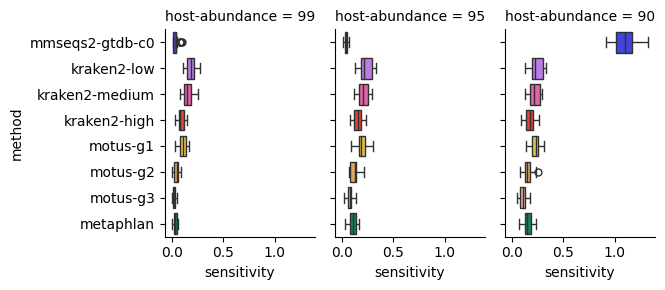

In [22]:
g = sns.catplot(
    data=test6_results, 
    x='sensitivity', y='method', hue='method', height=3.0, aspect=0.75,
    palette=method_palette, col='host-abundance', kind='box'
)
# g.savefig("../figures/draft0-figures/Fig1B.01.svg")

# g.ax.set_xscale('log')
# g.ax.set_yscale('log')

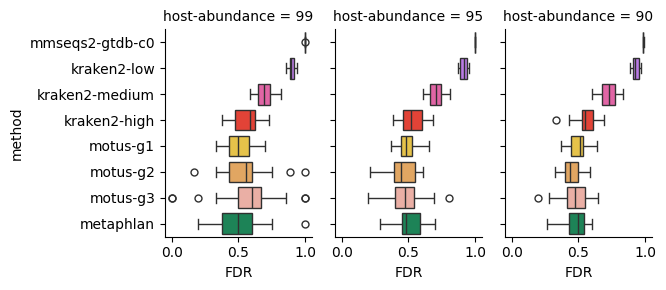

In [23]:
g = sns.catplot(
    data=test6_results, 
    x='FDR', y='method', hue='method', height=3.0, aspect=0.75,
    palette=method_palette, col='host-abundance', kind='box'
)
# g.set_yticklabels([])
# g.set_ylabels("")
# g.savefig("../figures/draft0-figures/Fig1B.02.svg")
# g.ax.set_xscale('log')
# g.ax.set_yscale('log')

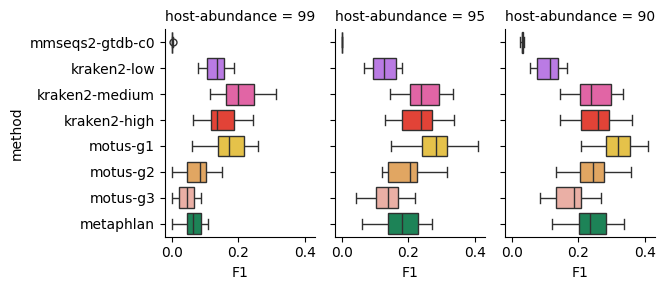

In [24]:
g = sns.catplot(
    data=test6_results, 
    x='F1', y='method', hue='method', height=3.0, aspect=0.75,
    palette=method_palette, col='host-abundance', kind='box'
)
# g.set_yticklabels([])
# g.set_ylabels("")
# g.savefig("../figures/draft0-figures/Fig1B.02.svg")
# g.ax.set_xscale('log')
# g.ax.set_yscale('log')

In [29]:
test6_results.groupby('method')[['sensitivity', 'FDR', 'F1', 'FPTP']].mean()

,sensitivity,FDR,F1,FPTP
method,,,,
kraken2-high,0.138959,0.544295,0.209612,1.284536
kraken2-low,0.220265,0.911532,0.124274,11.781740
kraken2-medium,0.193154,0.705309,0.230446,2.550925
metaphlan,0.099342,0.492298,0.158898,inf
mmseqs2-gtdb-c0,0.393945,0.994216,0.011400,1491.332771
motus-g1,0.176761,0.499922,0.255899,1.054658
motus-g2,0.107961,0.482288,0.173887,inf
motus-g3,0.070211,0.504251,0.119511,inf


In [30]:
test6_results.groupby('method')[['sensitivity', 'FDR', 'F1', 'FPTP']].std()

,sensitivity,FDR,F1,FPTP
method,,,,
kraken2-high,0.054792,0.090384,0.071587,0.472666
kraken2-low,0.063559,0.027875,0.035753,5.076107
kraken2-medium,0.059723,0.060308,0.057909,0.805124
metaphlan,0.061219,0.130714,0.087502,NaN
mmseqs2-gtdb-c0,0.506578,0.007386,0.014559,1541.526738
motus-g1,0.068346,0.078581,0.081788,0.363212
motus-g2,0.059031,0.133066,0.085452,NaN
motus-g3,0.043548,0.176053,0.069076,NaN


In [ ]:
test6_results['h'] = test6_results['host-abundance']
methods = ['kraken2-low', 'kraken2-high', 'kraken2-medium', 'motus-g1', 'motus-g2', 'motus-g3', 'metaphlan', 'mmseqs2-gtdb-c0']
f_oneway(
    *[test6_results.query('h == "90"').query('method == "{:s}"'.format(method))['F1'] for method in methods]
)

F_onewayResult(statistic=80.92646829600373, pvalue=7.287563071000573e-54)

In [70]:
def run_mutiple_dunnet_tests(data, methods):
    M = []
    for control in methods:
        
        dn = dunnett(
            *[data.query('method == "{:s}"'.format(method))['F1'] for method in methods if method != control],
            control=data.query('method == "{:s}"'.format(control))['F1'],
            alternative='less'
        )
        other_methods = [method for method in methods if method != control]
        for method, pvalue in zip(other_methods, dn.pvalue):
            M.append(
                {
                    "control": control,
                    "method": method,
                    "p-val":pvalue * len(methods),
                }
            )

    M = pd.DataFrame.from_records(M).pivot(index='control', columns='method', values='p-val')
    M['rank'] = M.index.map(method_index)
    M = M.sort_values(by='rank').drop(columns=['rank'])
    M = M.T 
    M['rank'] = M.index.map(method_index)
    M = M.sort_values(by='rank').drop(columns=['rank'])
    M = M.T 
    return M

In [71]:
M90 = run_mutiple_dunnet_tests(test6_results.query('h == "90"'), methods=methods)
M95 = run_mutiple_dunnet_tests(test6_results.query('h == "95"'), methods=methods)
M99 = run_mutiple_dunnet_tests(test6_results.query('h == "99"'), methods=methods)

In [74]:
M99

method,mmseqs2-gtdb-c0,kraken2-low,kraken2-medium,kraken2-high,motus-g1,motus-g2,motus-g3,metaphlan
control,,,,,,,,
mmseqs2-gtdb-c0,NaN,8.000000e+00,8.000000,8.000000,8.000000,8.000000e+00,8.000000e+00,8.000000e+00
kraken2-low,0.000000e+00,NaN,8.000000,7.985173,8.000000,8.480702e-05,2.966516e-13,5.926888e-08
kraken2-medium,0.000000e+00,6.373083e-09,NaN,0.000014,0.156152,0.000000e+00,0.000000e+00,0.000000e+00
kraken2-high,0.000000e+00,2.271120e+00,8.000000,NaN,7.999859,3.186282e-08,0.000000e+00,5.227818e-12
motus-g1,0.000000e+00,3.784259e-03,7.999969,0.323104,NaN,4.440892e-15,0.000000e+00,0.000000e+00
motus-g2,7.792700e-11,8.000000e+00,8.000000,8.000000,8.000000,NaN,3.330634e-02,2.014983e+00
motus-g3,2.390385e-03,8.000000e+00,8.000000,8.000000,8.000000,7.999999e+00,NaN,7.995920e+00
metaphlan,6.318341e-07,8.000000e+00,8.000000,8.000000,8.000000,7.989357e+00,1.393566e+00,NaN


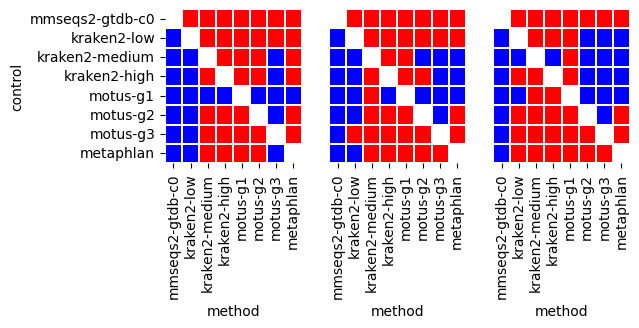

In [80]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(6, 2.0)
sns.heatmap(
    M90.clip(lower=0.04999, upper=0.05001),
    cmap='bwr', linecolor='white', linewidths=0.05, 
    mask=np.eye(len(methods), len(methods), dtype=bool), cbar=False,
    ax=ax[0]
)
sns.heatmap(
    M95.clip(lower=0.04999, upper=0.05001), 
    cmap='bwr', linecolor='white', linewidths=0.05, 
    mask=np.eye(len(methods), len(methods), dtype=bool),cbar=False,
    ax=ax[1], yticklabels=[]
)
sns.heatmap(
    M99.clip(lower=0.04999, upper=0.05001),
    cmap='bwr', linecolor='white', linewidths=0.05, 
    mask=np.eye(len(methods), len(methods), dtype=bool),cbar=False,
    ax=ax[2], yticklabels=[]
)
ax[1].set_ylabel("")
ax[2].set_ylabel("")
fig.savefig("figures/fig02.dunnet.svg")

In [44]:
methods = ['kraken2-low', 'kraken2-high', 'kraken2-medium', 'motus-g1', 'motus-g2', 'motus-g3', 'metaphlan', 'mmseqs2-gtdb-c0']
f_oneway(
    *[test6_results.query('h == "95"').query('method == "{:s}"'.format(method))['F1'] for method in methods]
)

F_onewayResult(statistic=71.6666001914168, pvalue=3.5694894278477523e-50)

In [45]:
methods = ['kraken2-low', 'kraken2-high', 'kraken2-medium', 'motus-g1', 'motus-g2', 'motus-g3', 'metaphlan', 'mmseqs2-gtdb-c0']
f_oneway(
    *[test6_results.query('h == "99"').query('method == "{:s}"'.format(method))['F1'] for method in methods]
)

F_onewayResult(statistic=83.15055298469596, pvalue=1.0537801510492583e-54)

In [46]:
levels = [90, 95, 99]
f_oneway(
    *[test6_results.query('h == "{:d}"'.format(level))['sensitivity'] for level in levels]
)

F_onewayResult(statistic=67.49774602031405, pvalue=3.7374768078911904e-27)

In [47]:
levels = [90, 95, 99]
f_oneway(
    *[test6_results.query('h == "{:d}"'.format(level))['FDR'] for level in levels]
)

F_onewayResult(statistic=0.672804920654195, pvalue=0.5106617615048237)

## Combining methods

In [45]:
metamotus_hits_df = pd.merge(
    motus_hits_df.query('method == "motus-g1"')[['label', 'ncbi_taxid', 'taxid']],
    metaphlan_hits_df[['label', 'ncbi_taxid']], on='label', suffixes=['_motus', '_meta']
)
metamotus_hits_df['ncbi_taxid'] = metamotus_hits_df.apply(lambda x: list(set(x['ncbi_taxid_motus'] + x['ncbi_taxid_meta'])), axis=1)
metamotus_hits_df['report'] = metamotus_hits_df.apply(lambda x: assess_taxonomic_classification_metrics(x.taxid, x.ncbi_taxid, ""), axis=1)
metamotus_hits_df['TP'] = metamotus_hits_df['report'].apply(lambda x: x['TP'])
metamotus_hits_df['FN'] = metamotus_hits_df['report'].apply(lambda x: x['FN'])
metamotus_hits_df['FP'] = metamotus_hits_df['report'].apply(lambda x: x['FP'])
metamotus_hits_df['Q'] = metamotus_hits_df['report'].apply(lambda x: x['Q'])
metamotus_hits_df['P'] = metamotus_hits_df['report'].apply(lambda x: x['P'])
metamotus_hits_df['sensitivity'] = metamotus_hits_df['report'].apply(lambda x: x['TP'] / (x['TP'] + x['FN']))
metamotus_hits_df['FDR'] = metamotus_hits_df['report'].apply(lambda x: x['FP'] / (x['TP'] + x['FP']))
metamotus_hits_df['host-abundance'] = metamotus_hits_df['label'].apply(lambda x: float(x.split('.')[-1][1:]))
metamotus_hits_df['method'] = 'metaphlan-motus-g1'
metamotus_hits_df

,label,ncbi_taxid_motus,taxid,ncbi_taxid_meta,ncbi_taxid,report,TP,FN,FP,Q,P,sensitivity,FDR,host-abundance,method
0,test-7.90.001,"[28901, 587753, 470, 1280, 81475, 1736471, 173...","[[69], [294], [305], [470], [550], [1393], [14...","[1736471, 81475, 550, 2596920, 1280, 2592640, ...","[1280, 2592640, 1736323, 459529, 1138189, 1652...","{'method': '', 'TP': 25, 'FP': 18, 'FN': 54, '...",25,54,18,79,43,0.316456,0.418605,1.0,metaphlan-motus-g1
1,test-7.90.002,"[28901, 587753, 470, 1280, 81475, 1736471, 173...","[[69], [294], [305], [470], [550], [1393], [14...","[2596920, 1382458, 305, 180957, 1280, 81475, 1...","[1280, 2592640, 1850370, 1736323, 459529, 5645...","{'method': '', 'TP': 28, 'FP': 28, 'FN': 51, '...",28,51,28,79,56,0.354430,0.500000,2.0,metaphlan-motus-g1
2,test-7.90.003,"[28901, 587753, 470, 1280, 1736471, 305, 305, ...","[[69], [294], [305], [470], [550], [1393], [14...","[160232, 357794, 1736356, 1652495, 28099, 860,...","[1280, 384, 1850370, 459529, 1138189, 1652495,...","{'method': '', 'TP': 28, 'FP': 22, 'FN': 51, '...",28,51,22,79,50,0.354430,0.440000,3.0,metaphlan-motus-g1
3,test-7.90.004,"[28901, 587753, 470, 1280, 1736471, 305, 305, ...","[[69], [294], [305], [470], [550], [1393], [14...","[69, 305, 713054, 1464, 28901, 160232, 860, 27...","[1280, 1736323, 107400, 1652495, 318996, 27636...","{'method': '', 'TP': 26, 'FP': 23, 'FN': 53, '...",26,53,23,79,49,0.329114,0.469388,4.0,metaphlan-motus-g1
4,test-7.90.005,"[28901, 587753, 1280, 1736471, 1736316, 305, 3...","[[69], [294], [305], [470], [550], [1393], [14...","[2596920, 1761874, 582672, 1078905, 2816249, 1...","[1280, 1736323, 107400, 56459, 1138189, 165249...","{'method': '', 'TP': 27, 'FP': 26, 'FN': 52, '...",27,52,26,79,53,0.341772,0.490566,5.0,metaphlan-motus-g1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,test-7.99.021,"[470, 1280, 92645, 83554, 47917, 1270, 582, 33...","[[292], [294], [346], [373], [550], [1270], [2...",[1280],"[1280, 1736576, 83554, 933059, 59620, 92645, 5...","{'method': '', 'TP': 7, 'FP': 9, 'FN': 78, 'P'...",7,78,9,85,16,0.082353,0.562500,21.0,metaphlan-motus-g1
71,test-7.99.022,"[1280, 47917, 1270, 1735685, 40324, 33010, 596...","[[292], [294], [346], [373], [550], [1270], [2...","[1280, 37482, 146786, 47917, 1736215, 1736587,...","[1280, 40324, 1735685, 1736329, 1736587, 17362...","{'method': '', 'TP': 10, 'FP': 9, 'FN': 73, 'P...",10,73,9,83,19,0.120482,0.473684,22.0,metaphlan-motus-g1
72,test-7.99.023,"[1280, 92645, 1138189, 427683, 1735685, 106592...","[[292], [294], [346], [373], [550], [1270], [2...","[37482, 2662446, 1736289, 427683, 1503981]","[1280, 1735685, 684552, 1138189, 1348249, 4276...","{'method': '', 'TP': 12, 'FP': 7, 'FN': 72, 'P...",12,72,7,84,19,0.142857,0.368421,23.0,metaphlan-motus-g1
73,test-7.99.024,"[470, 1280, 92645, 83554, 47917, 1270, 61624, ...","[[292], [294], [346], [373], [550], [1270], [2...","[53972, 2919927, 104623, 1736289, 2594882]","[1280, 40324, 1735685, 1736329, 1736587, 17356...","{'method': '', 'TP': 16, 'FP': 10, 'FN': 69, '...",16,69,10,85,26,0.188235,0.384615,24.0,metaphlan-motus-g1


In [46]:
test6_results = pd.concat([kraken2_hits_df, motus_hits_df, metaphlan_hits_df, gtdb_hits_df, metamotus_hits_df])
test6_results['FDR'] = test6_results['FP'] / (test6_results['FP'] + test6_results['TP'])
test6_results['F1'] = 2 * test6_results['TP'] / ((2 * test6_results['TP']) + test6_results['FN'] + test6_results['FP'])
test6_results['host-abundance'] = test6_results['label'].apply(lambda x: x.split('.')[1])

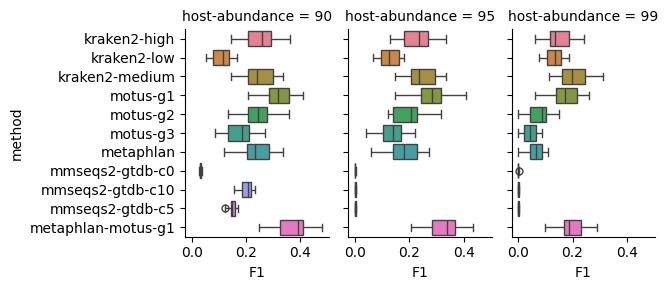

In [47]:
g = sns.catplot(
    data=test6_results.reset_index(), 
    x='F1', y='method', hue='method', height=3.0, aspect=0.75,
    col='host-abundance', kind='box'
)

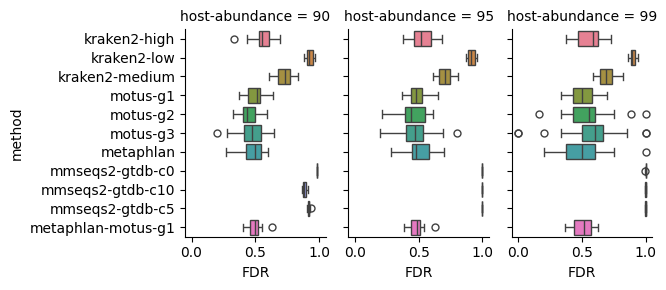

In [48]:
g = sns.catplot(
    data=test6_results.reset_index(), 
    x='FDR', y='method', hue='method', height=3.0, aspect=0.75,
    col='host-abundance', kind='box'
)

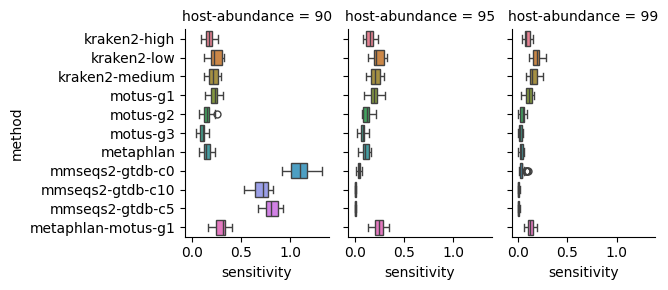

In [49]:
g = sns.catplot(
    data=test6_results.reset_index(), 
    x='sensitivity', y='method', hue='method', height=3.0, aspect=0.75,
    col='host-abundance', kind='box'
)

In [50]:
metamotus_hits_df['overlap'] = metamotus_hits_df.apply(
    lambda x: len([item for item in x.ncbi_taxid_motus if item in x.ncbi_taxid_meta]) / min(len(x.ncbi_taxid_motus), len(x.ncbi_taxid_meta)),axis=1
)

In [51]:
metamotus_hits_df

,label,ncbi_taxid_motus,taxid,ncbi_taxid_meta,ncbi_taxid,report,TP,FN,FP,Q,P,sensitivity,FDR,host-abundance,method,overlap
0,test-7.90.001,"[28901, 587753, 470, 1280, 81475, 1736471, 173...","[[69], [294], [305], [470], [550], [1393], [14...","[1736471, 81475, 550, 2596920, 1280, 2592640, ...","[1280, 2592640, 1736323, 459529, 1138189, 1652...","{'method': '', 'TP': 25, 'FP': 18, 'FN': 54, '...",25,54,18,79,43,0.316456,0.418605,1.0,metaphlan-motus-g1,0.588235
1,test-7.90.002,"[28901, 587753, 470, 1280, 81475, 1736471, 173...","[[69], [294], [305], [470], [550], [1393], [14...","[2596920, 1382458, 305, 180957, 1280, 81475, 1...","[1280, 2592640, 1850370, 1736323, 459529, 5645...","{'method': '', 'TP': 28, 'FP': 28, 'FN': 51, '...",28,51,28,79,56,0.354430,0.500000,2.0,metaphlan-motus-g1,0.600000
2,test-7.90.003,"[28901, 587753, 470, 1280, 1736471, 305, 305, ...","[[69], [294], [305], [470], [550], [1393], [14...","[160232, 357794, 1736356, 1652495, 28099, 860,...","[1280, 384, 1850370, 459529, 1138189, 1652495,...","{'method': '', 'TP': 28, 'FP': 22, 'FN': 51, '...",28,51,22,79,50,0.354430,0.440000,3.0,metaphlan-motus-g1,0.718750
3,test-7.90.004,"[28901, 587753, 470, 1280, 1736471, 305, 305, ...","[[69], [294], [305], [470], [550], [1393], [14...","[69, 305, 713054, 1464, 28901, 160232, 860, 27...","[1280, 1736323, 107400, 1652495, 318996, 27636...","{'method': '', 'TP': 26, 'FP': 23, 'FN': 53, '...",26,53,23,79,49,0.329114,0.469388,4.0,metaphlan-motus-g1,0.750000
4,test-7.90.005,"[28901, 587753, 1280, 1736471, 1736316, 305, 3...","[[69], [294], [305], [470], [550], [1393], [14...","[2596920, 1761874, 582672, 1078905, 2816249, 1...","[1280, 1736323, 107400, 56459, 1138189, 165249...","{'method': '', 'TP': 27, 'FP': 26, 'FN': 52, '...",27,52,26,79,53,0.341772,0.490566,5.0,metaphlan-motus-g1,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,test-7.99.021,"[470, 1280, 92645, 83554, 47917, 1270, 582, 33...","[[292], [294], [346], [373], [550], [1270], [2...",[1280],"[1280, 1736576, 83554, 933059, 59620, 92645, 5...","{'method': '', 'TP': 7, 'FP': 9, 'FN': 78, 'P'...",7,78,9,85,16,0.082353,0.562500,21.0,metaphlan-motus-g1,1.000000
71,test-7.99.022,"[1280, 47917, 1270, 1735685, 40324, 33010, 596...","[[292], [294], [346], [373], [550], [1270], [2...","[1280, 37482, 146786, 47917, 1736215, 1736587,...","[1280, 40324, 1735685, 1736329, 1736587, 17362...","{'method': '', 'TP': 10, 'FP': 9, 'FN': 73, 'P...",10,73,9,83,19,0.120482,0.473684,22.0,metaphlan-motus-g1,0.888889
72,test-7.99.023,"[1280, 92645, 1138189, 427683, 1735685, 106592...","[[292], [294], [346], [373], [550], [1270], [2...","[37482, 2662446, 1736289, 427683, 1503981]","[1280, 1735685, 684552, 1138189, 1348249, 4276...","{'method': '', 'TP': 12, 'FP': 7, 'FN': 72, 'P...",12,72,7,84,19,0.142857,0.368421,23.0,metaphlan-motus-g1,0.600000
73,test-7.99.024,"[470, 1280, 92645, 83554, 47917, 1270, 61624, ...","[[292], [294], [346], [373], [550], [1270], [2...","[53972, 2919927, 104623, 1736289, 2594882]","[1280, 40324, 1735685, 1736329, 1736587, 17356...","{'method': '', 'TP': 16, 'FP': 10, 'FN': 69, '...",16,69,10,85,26,0.188235,0.384615,24.0,metaphlan-motus-g1,0.400000
